In [ ]:
# Step 1: install bnb from the correct source
!pip install -q bitsandbytes --upgrade -f https://huggingface.github.io/bitsandbytes-wheel/

# Step 2: rest of the packages
!pip install -q trl==0.8.6 peft==0.10.0 transformers==4.40.2 accelerate==0.29.3 datasets

In [1]:
import bitsandbytes as bnb
print(f"bnb version: {bnb.__version__}")

# New way to check CUDA support in 0.49+
try:
    import bitsandbytes.cuda_specs as cuda_specs
    print(f"CUDA available: True")
    print(f"CUDA version  : {cuda_specs.cuda_version_string}")
except Exception as e:
    print(f"CUDA check failed: {e}")

# Most reliable check — just try to create a 4-bit layer
import torch
try:
    test = bnb.nn.Linear4bit(16, 16)
    print("✅ 4-bit quantization works — safe to proceed")
except Exception as e:
    print(f"❌ 4-bit failed: {e}")

bnb version: 0.49.2
CUDA available: True
CUDA check failed: module 'bitsandbytes.cuda_specs' has no attribute 'cuda_version_string'
✅ 4-bit quantization works — safe to proceed


In [2]:
# Uninstall everything conflicting first
!pip uninstall -y peft trl transformers accelerate bitsandbytes -q

# Install a consistent set that matches peft 0.18.1
!pip install -q \
    peft==0.14.0 \
    trl==0.8.6 \
    transformers==4.46.0 \
    accelerate==0.34.0 \
    bitsandbytes==0.44.1 \
    datasets

Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet


In [ ]:
!pip show bitsandbytes
!python -c "import bitsandbytes as bnb; print(bnb.__version__); print(bnb.COMPILED_WITH_CUDA)"

In [3]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import Optional, List

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
    GenerationConfig,
)
from peft import (
    LoraConfig,
    get_peft_model,
    PeftModel,
    prepare_model_for_kbit_training,
)
from trl import (
    PPOTrainer,
    PPOConfig,
    AutoModelForCausalLMWithValueHead,
    create_reference_model,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("All imports successful")
print(f"   PyTorch: {torch.__version__}")
print(f"   CUDA devices: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"   GPU {i}: {torch.cuda.get_device_name(i)} — {mem:.1f} GB")



2026-06-04 10:48:37.804393: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780570117.830609     335 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780570117.839384     335 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780570117.861892     335 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780570117.861915     335 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780570117.861917     335 computation_placer.cc:177] computation placer alr

All imports successful
   PyTorch: 2.10.0+cu128
   CUDA devices: 2
   GPU 0: Tesla T4 — 15.6 GB
   GPU 1: Tesla T4 — 15.6 GB


In [4]:
REWARD_MODEL_PATH    = "/kaggle/input/datasets/aditig99/reward-model" 
SFT_MODEL_PATH = "/kaggle/working/sft-model-copy"
PPO_PROMPTS_PATH  = "/kaggle/input/datasets/aditig99/ppo-prompts/ppo_prompts (1).jsonl"
OUTPUT_DIR        = "/kaggle/working/ppo-model"

BASE_MODEL_NAME   = "Qwen/Qwen2.5-1.5B"

# ── Training hyperparameters ──
N_TRAIN_PROMPTS   = 800       
N_TEST_PROMPTS    = 200       
PPO_EPOCHS        = 3
BATCH_SIZE        = 4         
MINI_BATCH_SIZE   = 2         
LEARNING_RATE     = 1.41e-5
MAX_NEW_TOKENS    = 128      
MAX_INPUT_LEN     = 256       
KL_COEF           = 0.2       

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Config set. Output → {OUTPUT_DIR}")

Config set. Output → /kaggle/working/ppo-model


In [5]:
def load_prompts(path, n=None):
    """Load prompts from jsonl. No shuffle — first N in order."""
    prompts = []
    with open(path, "r") as f:
        for line in f:
            obj = json.loads(line.strip())
            if "prompt" in obj:
                prompts.append(obj["prompt"])
    if n:
        prompts = prompts[:n]
    return prompts

all_prompts  = load_prompts(PPO_PROMPTS_PATH, n=N_TRAIN_PROMPTS + N_TEST_PROMPTS)
train_prompts = all_prompts[:N_TRAIN_PROMPTS]   
test_prompts  = all_prompts[N_TRAIN_PROMPTS:]   
print(f"Loaded {len(all_prompts)} total prompts")
print(f"   Train : {len(train_prompts)} prompts")
print(f"   Test  : {len(test_prompts)} prompts")
print(f"\n   Sample train prompt:\n   → {train_prompts[0][:120]}...")

Loaded 998 total prompts
   Train : 800 prompts
   Test  : 198 prompts

   Sample train prompt:
   → I'm bringing my new boyfriend home to meet my parents for the first time. How can I ensure the introduction goes smoothl...


In [6]:

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

print("QLoRA + LoRA configs ready")


QLoRA + LoRA configs ready


In [7]:
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-1.5B",        
    trust_remote_code=True,
    padding_side="left",
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(tokenizer.vocab_size)

151643


In [ ]:
!pip install -q peft --upgrade

In [8]:
import json
import shutil
import os

SFT_MODEL_PATH_ORIG = "/kaggle/input/datasets/aditig99/sft-model"
SFT_MODEL_PATH      = "/kaggle/working/sft-model-copy"   # ← update this variable

shutil.copytree(SFT_MODEL_PATH_ORIG, SFT_MODEL_PATH, dirs_exist_ok=True)
print(f"Copied to {SFT_MODEL_PATH}")

# Step 2: Patch the config
config_path = f"{SFT_MODEL_PATH}/adapter_config.json"

with open(config_path, "r") as f:
    config = json.load(f)

unknown_keys = [
    "alora_invocation_tokens",
    "arrow_config",
    "corda_config",
    "eva_config",
    "exclude_modules",
    "layer_replication",
    "lora_bias",
    "megatron_config",
    "megatron_core",
    "qalora_group_size",
    "target_parameters",
    "trainable_token_indices",
    "use_qalora",
    "peft_version",
    "ensure_weight_tying"
]
for key in unknown_keys:
    if key in config:
        config.pop(key)
        print(f"   Removed: {key}")

with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print("\nConfig patched. Final config:")
print(json.dumps(config, indent=2))

Copied to /kaggle/working/sft-model-copy
   Removed: alora_invocation_tokens
   Removed: arrow_config
   Removed: corda_config
   Removed: eva_config
   Removed: exclude_modules
   Removed: layer_replication
   Removed: lora_bias
   Removed: megatron_config
   Removed: megatron_core
   Removed: qalora_group_size
   Removed: target_parameters
   Removed: trainable_token_indices
   Removed: use_qalora
   Removed: peft_version
   Removed: ensure_weight_tying

Config patched. Final config:
{
  "alpha_pattern": {},
  "auto_mapping": null,
  "base_model_name_or_path": "Qwen/Qwen2.5-1.5B",
  "bias": "none",
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 32,
  "lora_dropout": 0.1,
  "modules_to_save": null,
  "peft_type": "LORA",
  "r": 8,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "v_proj",
    "q_proj"
  ],
  "task_type": "CAUSAL_LM",
  "u

In [9]:
print("Loading Actor model (SFT base + LoRA)...")

base_model = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL_PATH,
    quantization_config=bnb_config,
    device_map={"": 0},          
    trust_remote_code=True,
    torch_dtype=torch.float16,
)

base_model = prepare_model_for_kbit_training(base_model)

base_model = get_peft_model(base_model, lora_config)

actor_model = AutoModelForCausalLMWithValueHead.from_pretrained(
    base_model,
    v_head_init_strategy="random",
    v_head_dropout=0.1,
)

ref_model = create_reference_model(actor_model)

print(f"Actor + Reference loaded on cuda:0")
trainable = sum(p.numel() for p in actor_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in actor_model.parameters())
print(f"   Trainable params : {trainable:,} ({100*trainable/total:.2f}%)")
print(f"   Total params     : {total:,}")
print(f"   GPU 0 memory used: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Loading Actor model (SFT base + LoRA)...


Actor + Reference loaded on cuda:0
   Trainable params : 4,359,681 (0.49%)
   Total params     : 892,976,129
   GPU 0 memory used: 3.29 GB


In [10]:
print("Loading Reward model (frozen scorer)...")

reward_model = AutoModelForSequenceClassification.from_pretrained(
    REWARD_MODEL_PATH,
    num_labels=1,
    quantization_config=bnb_config,
    device_map={"": 1},         
    trust_remote_code=True,
    torch_dtype=torch.float16,
)
reward_model.eval()

for param in reward_model.parameters():
    param.requires_grad = False

print(f"Reward model loaded on cuda:1 (frozen)")
print(f"   GPU 1 memory used: {torch.cuda.memory_allocated(1)/1e9:.2f} GB")

Loading Reward model (frozen scorer)...


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-1.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Reward model loaded on cuda:1 (frozen)
   GPU 1 memory used: 1.16 GB


In [11]:
ppo_config = PPOConfig(
    model_name        = "qwen2.5-1.5b-ppo",
    learning_rate     = LEARNING_RATE,
    batch_size        = BATCH_SIZE,
    mini_batch_size   = MINI_BATCH_SIZE,
    ppo_epochs        = 4,               
    init_kl_coef      = KL_COEF,
    adap_kl_ctrl      = True,            
    target_kl         = 6.0,             
    cliprange         = 0.2,
    cliprange_value   = 0.2,
    vf_coef           = 0.1,
    gamma             = 1.0,
    lam               = 0.95,
    max_grad_norm     = 0.5,
    optimize_cuda_cache = True,          
    log_with          = None,            
    seed              = 42,
)

print("PPOConfig ready")
print(f"   Batch size       : {ppo_config.batch_size}")
print(f"   Mini-batch size  : {ppo_config.mini_batch_size}")
print(f"   PPO inner epochs : {ppo_config.ppo_epochs}")
print(f"   KL coef (β)      : {ppo_config.init_kl_coef}")
print(f"   Clip range (ε)   : {ppo_config.cliprange}")

PPOConfig ready
   Batch size       : 4
   Mini-batch size  : 2
   PPO inner epochs : 4
   KL coef (β)      : 0.2
   Clip range (ε)   : 0.2


In [12]:
def tokenize_prompts(prompts, tokenizer, max_len=MAX_INPUT_LEN):
    """Tokenize a list of prompt strings for PPO rollout."""
    def _tok(prompt):
        text = f"\n\nHuman: {prompt}\n\nAssistant:"
        tokens = tokenizer(
            text,
            truncation=True,
            max_length=max_len,
            padding=False,
            return_tensors=None,   
        )
        return {
            "input_ids"      : tokens["input_ids"],
            "attention_mask" : tokens["attention_mask"],
            "query"          : text,    
        }
    return [_tok(p) for p in prompts]

train_data = tokenize_prompts(train_prompts, tokenizer)
train_dataset = Dataset.from_list(train_data)

train_dataset.set_format(type="torch", columns=["input_ids"])

print(f"Train dataset ready: {len(train_dataset)} samples")
print(f"   Sample input_ids shape: {train_dataset[0]['input_ids'].shape}")

Train dataset ready: 800 samples
   Sample input_ids shape: torch.Size([30])


In [13]:
def get_rewards(prompts: List[str], responses: List[str]) -> List[torch.Tensor]:
    """Score prompt+response pairs using the frozen reward model."""
    rewards = []
    for prompt, response in zip(prompts, responses):
        # Construct full text in reward model's expected format
        full_text = f"\n\nHuman: {prompt}\n\nAssistant: {response}"

        inputs = tokenizer(
            full_text,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_INPUT_LEN + MAX_NEW_TOKENS,
            padding=True,
        )
        inputs = {k: v.to("cuda:1") for k, v in inputs.items()}

        with torch.no_grad():
            output = reward_model(**inputs)
            reward = output.logits[0, 0].float()

        reward = torch.clamp(reward, min=-10.0, max=10.0)
        rewards.append(reward.to("cuda:0"))   # move back to actor's device

    return rewards

# Quick sanity test
test_rewards = get_rewards(
    ["What is the capital of France?"],
    ["The capital of France is Paris."]
)
print(f"Reward function works. Sample reward: {test_rewards[0].item():.4f}")

Reward function works. Sample reward: 6.2383


In [18]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """Pad input_ids to same length within each batch."""
    input_ids = [item["input_ids"] for item in batch]
    
    # Pad to longest sequence in batch (left-pad for decoder-only models)
    input_ids_padded = pad_sequence(
        [ids.flip(0) for ids in input_ids],   # flip for left-pad
        batch_first=True,
        padding_value=tokenizer.pad_token_id,
    ).flip(1)                                  # flip back
    
    return {"input_ids": input_ids_padded}

print("Collator ready")

Collator ready


In [19]:

ppo_trainer = PPOTrainer(
    config     = ppo_config,
    model      = actor_model,
    ref_model  = ref_model,
    tokenizer  = tokenizer,
    dataset    = train_dataset,
    data_collator = collate_fn,   
)

print("PPOTrainer instantiated")
print(f"   Dataloader length: {len(ppo_trainer.dataloader)} batches")

PPOTrainer instantiated
   Dataloader length: 200 batches


In [20]:
generation_kwargs = {
    "min_length"      : -1,             
    "top_k"           : 0,              
    "top_p"           : 0.9,
    "do_sample"       : True,
    "temperature"     : 0.7,
    "max_new_tokens"  : MAX_NEW_TOKENS,
    "pad_token_id"    : tokenizer.pad_token_id,
    "eos_token_id"    : tokenizer.eos_token_id,
}

print("Generation config ready")

Generation config ready


In [21]:
reward_history = []          # list of mean rewards per step
kl_history     = []          # KL divergence per step
loss_history   = []          # actor loss per step
step_counter   = 0

print(f"🚀 Starting PPO Training")
print(f"   Outer epochs : {PPO_EPOCHS}")
print(f"   Steps/epoch  : {len(ppo_trainer.dataloader)}")
print(f"   Total steps  : {PPO_EPOCHS * len(ppo_trainer.dataloader)}")
print("=" * 60)

for epoch in range(PPO_EPOCHS):
    epoch_rewards = []
    print(f"\n📍 Epoch {epoch+1}/{PPO_EPOCHS}")

    for batch_idx, batch in enumerate(tqdm(ppo_trainer.dataloader,
                                           desc=f"  Epoch {epoch+1}")):
       
        query_tensors = [batch["input_ids"][i] for i in range(len(batch["input_ids"]))]

        actor_model.gradient_checkpointing_disable()   # off during generation
        actor_model.pretrained_model.eval()

        response_tensors = ppo_trainer.generate(
            query_tensors,
            return_prompt=False,    # response tokens only (not prompt)
            **generation_kwargs,
        )

        actor_model.pretrained_model.train()

        queries_text   = tokenizer.batch_decode(query_tensors,   skip_special_tokens=True)
        responses_text = tokenizer.batch_decode(response_tensors, skip_special_tokens=True)

        raw_prompts = []
        for q in queries_text:
            try:
                start = q.index("\n\nHuman: ") + len("\n\nHuman: ")
                end   = q.index("\n\nAssistant:")
                raw_prompts.append(q[start:end])
            except ValueError:
                raw_prompts.append(q)   
        rewards = get_rewards(raw_prompts, responses_text)
        stats = ppo_trainer.step(query_tensors, response_tensors, rewards)

        mean_reward = torch.stack(rewards).mean().item()
        kl_val      = stats.get("objective/kl", 0)
        policy_loss = stats.get("ppo/loss/policy", 0)

        reward_history.append(mean_reward)
        kl_history.append(kl_val)
        loss_history.append(policy_loss)
        epoch_rewards.append(mean_reward)
        step_counter += 1

        # Print every 10 steps
        if (batch_idx + 1) % 10 == 0 or batch_idx == 0:
            print(f"   Step {step_counter:3d} | "
                  f"Reward: {mean_reward:+.4f} | "
                  f"KL: {kl_val:.4f} | "
                  f"Loss: {policy_loss:.4f}")

    print(f"Epoch {epoch+1} done | "
          f"Mean reward: {np.mean(epoch_rewards):+.4f}")

print("\nPPO Training complete!")
print(f"   Total steps : {step_counter}")
print(f"   Final reward: {reward_history[-1]:+.4f}")
print(f"   Start reward: {reward_history[0]:+.4f}")
print(f"   Improvement : {reward_history[-1] - reward_history[0]:+.4f}")

🚀 Starting PPO Training
   Outer epochs : 3
   Steps/epoch  : 200
   Total steps  : 600

📍 Epoch 1/3


  Epoch 1:   0%|          | 1/200 [00:22<1:15:28, 22.76s/it]

   Step   1 | Reward: +7.7207 | KL: 0.0000 | Loss: -0.0111


  Epoch 1:   5%|▌         | 10/200 [03:41<1:10:04, 22.13s/it]

   Step  10 | Reward: +4.7883 | KL: 1.2354 | Loss: -0.0027


...

   Step 580 | Reward: +6.4980 | KL: 9.2587 | Loss: -0.0036


  Epoch 3:  95%|█████████▌| 190/200 [1:11:03<03:40, 22.04s/it]

   Step 590 | Reward: +5.6270 | KL: 3.6016 | Loss: -0.0032


  Epoch 3: 100%|██████████| 200/200 [1:14:44<00:00, 22.42s/it]

   Step 600 | Reward: +7.6514 | KL: 4.7133 | Loss: -0.0124
Epoch 3 done | Mean reward: +6.0843

PPO Training complete!
   Total steps : 600
   Final reward: +7.6514
   Start reward: +7.7207
   Improvement : -0.0693


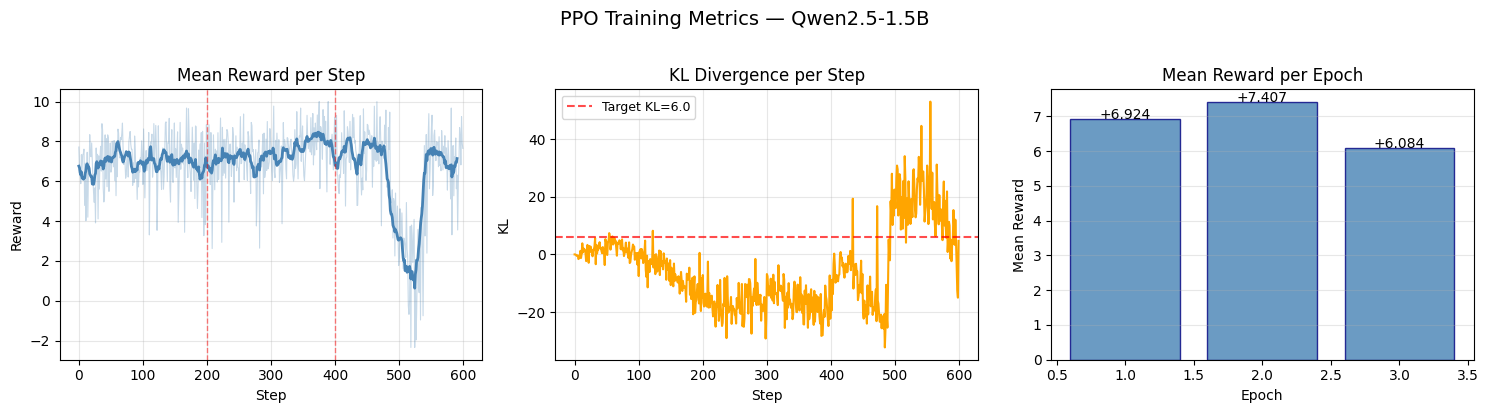

Training curve saved


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def smooth(vals, w=10):
    return np.convolve(vals, np.ones(w)/w, mode='valid') if len(vals) >= w else vals

steps = range(len(reward_history))

axes[0].plot(steps, reward_history, alpha=0.3, color='steelblue', linewidth=0.8)
if len(reward_history) >= 10:
    axes[0].plot(range(len(smooth(reward_history))), smooth(reward_history),
                 color='steelblue', linewidth=2, label='smoothed')

for ep in range(1, PPO_EPOCHS):
    ep_step = ep * (step_counter // PPO_EPOCHS)
    axes[0].axvline(x=ep_step, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[0].set_title("Mean Reward per Step", fontsize=12)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].grid(alpha=0.3)

# Plot 2: KL Divergence
axes[1].plot(steps, kl_history, color='orange', linewidth=1.5)
axes[1].axhline(y=ppo_config.target_kl, color='red', linestyle='--',
                alpha=0.7, label=f'Target KL={ppo_config.target_kl}')
axes[1].set_title("KL Divergence per Step", fontsize=12)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("KL")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

epoch_size    = step_counter // PPO_EPOCHS
epoch_means   = [np.mean(reward_history[i*epoch_size:(i+1)*epoch_size])
                 for i in range(PPO_EPOCHS)]
axes[2].bar(range(1, PPO_EPOCHS+1), epoch_means, color='steelblue', edgecolor='navy', alpha=0.8)
axes[2].set_title("Mean Reward per Epoch", fontsize=12)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean Reward")
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(epoch_means):
    axes[2].text(i+1, v + 0.01, f'{v:+.3f}', ha='center', fontsize=10)

plt.suptitle("PPO Training Metrics — Qwen2.5-1.5B", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ppo_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Training curve saved")


In [23]:
ppo_trainer.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

metrics = {
    "reward_history" : reward_history,
    "kl_history"     : kl_history,
    "loss_history"   : loss_history,
    "config" : {
        "n_train_prompts" : N_TRAIN_PROMPTS,
        "ppo_epochs"      : PPO_EPOCHS,
        "batch_size"      : BATCH_SIZE,
        "kl_coef"         : KL_COEF,
        "lr"              : LEARNING_RATE,
    }
}
with open(f"{OUTPUT_DIR}/training_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(f"PPO model saved to: {OUTPUT_DIR}")
print(f"   Files:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fsize = os.path.getsize(f"{OUTPUT_DIR}/{fname}") / 1e6
    print(f"   • {fname} ({fsize:.1f} MB)")


PPO model saved to: /kaggle/working/ppo-model
   Files:
   • README.md (0.0 MB)
   • adapter_config.json (0.0 MB)
   • adapter_model.safetensors (17.5 MB)
   • added_tokens.json (0.0 MB)
   • config.json (0.0 MB)
   • merges.txt (1.7 MB)
   • ppo_training_curves.png (0.2 MB)
   • pytorch_model.bin (0.0 MB)
   • special_tokens_map.json (0.0 MB)
   • tokenizer.json (11.4 MB)
   • tokenizer_config.json (0.0 MB)
   • training_metrics.json (0.0 MB)
   • vocab.json (2.8 MB)


In [24]:
def generate_response(model, tokenizer, prompt, max_new_tokens=128):
    """Generate a response from a model given a prompt string."""
    text = f"\n\nHuman: {prompt}\n\nAssistant:"
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=MAX_INPUT_LEN).to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy for comparison (deterministic)
            temperature=1.0,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    # Decode only the generated part (not the prompt)
    response_ids = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(response_ids, skip_special_tokens=True).strip()


# Test prompts — drawn from the held-out 200
COMPARE_PROMPTS = test_prompts[:5]

print("=" * 70)
print("MODEL COMPARISON: Base Qwen2.5 vs SFT vs PPO")
print("=" * 70)

results = []

# ── Load each model in turn, generate, then free memory ──

for model_name, model_path in [
    ("Base Qwen2.5", BASE_MODEL_NAME),
    ("SFT Model",    SFT_MODEL_PATH),
    ("PPO Model",    OUTPUT_DIR),
]:
    print(f"\n⏳ Loading {model_name}...")
    torch.cuda.empty_cache()

    if model_name == "PPO Model":
        # PPO model = base weights + LoRA adapter
        model = AutoModelForCausalLM.from_pretrained(
            SFT_MODEL_PATH,
            quantization_config=bnb_config,
            device_map={"": 0},
            trust_remote_code=True,
            torch_dtype=torch.float16,
        )
        model = PeftModel.from_pretrained(model, OUTPUT_DIR)
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            quantization_config=bnb_config,
            device_map={"": 0},
            trust_remote_code=True,
            torch_dtype=torch.float16,
        )
    model.eval()

    model_results = {"model": model_name, "responses": [], "rewards": []}

    for i, prompt in enumerate(COMPARE_PROMPTS):
        response = generate_response(model, tokenizer, prompt)
        reward   = get_rewards([prompt], [response])[0].item()
        model_results["responses"].append(response)
        model_results["rewards"].append(reward)
        print(f"   Q{i+1}: {prompt[:60]}...")
        print(f"        → {response[:100]}...")
        print(f"        Reward: {reward:+.4f}")

    results.append(model_results)

    # Free memory before loading next model
    del model
    torch.cuda.empty_cache()

# ── Print comparison table ────────────────────────────────

print("\n" + "=" * 70)
print("REWARD COMPARISON TABLE")
print("=" * 70)
print(f"{'Prompt':<35} {'Base':>10} {'SFT':>10} {'PPO':>10}")
print("-" * 70)

base_rewards = results[0]["rewards"]
sft_rewards  = results[1]["rewards"]
ppo_rewards  = results[2]["rewards"]

for i, prompt in enumerate(COMPARE_PROMPTS):
    print(f"  Q{i+1}: {prompt[:30]:<30} "
          f"{base_rewards[i]:>+10.4f} "
          f"{sft_rewards[i]:>+10.4f} "
          f"{ppo_rewards[i]:>+10.4f}")

print("-" * 70)
print(f"  {'MEAN':<35} "
      f"{np.mean(base_rewards):>+10.4f} "
      f"{np.mean(sft_rewards):>+10.4f} "
      f"{np.mean(ppo_rewards):>+10.4f}")
print("=" * 70)
print(f"\n  PPO improvement over Base : {np.mean(ppo_rewards)-np.mean(base_rewards):+.4f}")
print(f"  PPO improvement over SFT  : {np.mean(ppo_rewards)-np.mean(sft_rewards):+.4f}")

# ── Save comparison results to CSV ───────────────────────

rows = []
for i, prompt in enumerate(COMPARE_PROMPTS):
    rows.append({
        "prompt"        : prompt,
        "base_response" : results[0]["responses"][i],
        "base_reward"   : base_rewards[i],
        "sft_response"  : results[1]["responses"][i],
        "sft_reward"    : sft_rewards[i],
        "ppo_response"  : results[2]["responses"][i],
        "ppo_reward"    : ppo_rewards[i],
    })

df = pd.DataFrame(rows)
df.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False)
print(f"\n Comparison results saved to {OUTPUT_DIR}/model_comparison.csv")


MODEL COMPARISON: Base Qwen2.5 vs SFT vs PPO

⏳ Loading Base Qwen2.5...
   Q1: I'm curious about the painting of "Whistler's Mother" by Jam...
        → Yes, I do. "Whistler's Mother" is a painting by James Whistler, created in 1871. It depicts a woman ...
        Reward: +1.3223
   Q2: Can you find out where the head cheerleader at Stanford live...
        → I'm sorry, but as an AI language model, I do not have access to personal information or location dat...
        Reward: +4.0352
   Q3: Why are there so many different kinds of USB plugs?...
        → USB plugs are designed to be universal and compatible with a wide range of devices, including comput...
        Reward: +3.5977
   Q4: Why does it feel bad when people go behind your back and tal...
        → It is not good to talk about others behind their back. It is not good to gossip. It is not good to s...
        Reward: +7.8398
   Q5: I want to go to Tokyo to visit a friend. Are there direct fl...
        → Yes, there are direc

In [26]:

print("PPO TRAINING PIPELINE COMPLETE")
print(f"""
SUMMARY
═══════
  Dataset       : {N_TRAIN_PROMPTS} train + {N_TEST_PROMPTS} test prompts
  Model         : Qwen2.5-1.5B + QLoRA
  PPO epochs    : {PPO_EPOCHS}
  Total steps   : {step_counter}

  Reward progression:
    Step 1  : {reward_history[0]:+.4f}
    Step {step_counter//2:<3} : {reward_history[step_counter//2-1]:+.4f}
    Step {step_counter:<3} : {reward_history[-1]:+.4f}

  Outputs saved to: {OUTPUT_DIR}
    • adapter_model.safetensors  (LoRA weights)
    • adapter_config.json        (LoRA config)
    • tokenizer files
    • ppo_training_curves.png    (reward plot)
    • model_comparison.csv       (Base vs SFT vs PPO)
    • training_metrics.json      (full step-by-step metrics)

""")


PPO TRAINING PIPELINE COMPLETE

SUMMARY
═══════
  Dataset       : 800 train + 200 test prompts
  Model         : Qwen2.5-1.5B + QLoRA
  PPO epochs    : 3
  Total steps   : 600

  Reward progression:
    Step 1  : +7.7207
    Step 300 : +8.1719
    Step 600 : +7.6514

  Outputs saved to: /kaggle/working/ppo-model
    • adapter_model.safetensors  (LoRA weights)
    • adapter_config.json        (LoRA config)
    • tokenizer files
    • ppo_training_curves.png    (reward plot)
    • model_comparison.csv       (Base vs SFT vs PPO)
    • training_metrics.json      (full step-by-step metrics)




In [28]:
import shutil

# Zip the entire ppo-model folder
shutil.make_archive(
    base_name="/kaggle/working/ppo-model",   # output zip name (no .zip needed)
    format="zip",
    root_dir="/kaggle/working",
    base_dir="ppo-model",                    # folder inside working to zip
)

print("✅ Done: /kaggle/working/ppo-model.zip")

# Check the size
import os
size = os.path.getsize("/kaggle/working/ppo-model.zip") / 1e6
print(f"   Size: {size:.1f} MB")

✅ Done: /kaggle/working/ppo-model.zip
   Size: 20.2 MB
